# IN5437 — Assignment 1
## Question 4: Otsu Thresholding + Foreground Histogram Equalization

**Name:** Benjamine  
**Index:** 258762A

- (a) Convert to grayscale, apply Otsu thresholding, report the threshold value.
- (b) Apply histogram equalization only to the foreground (woman + room) and observe the hidden features revealed.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read the image directly in grayscale (same style as Q1 and Q3)
q4_im = cv.imread('../images/woman_open_door.jpg', cv.IMREAD_GRAYSCALE)
assert q4_im is not None, "File could not be read. Check the path."
print('Shape:', q4_im.shape, '| Min:', q4_im.min(), '| Max:', q4_im.max(), '| Mean:', round(float(q4_im.mean()), 2))

Shape: (5867, 4693) | Min: 0 | Max: 255 | Mean: 27.63


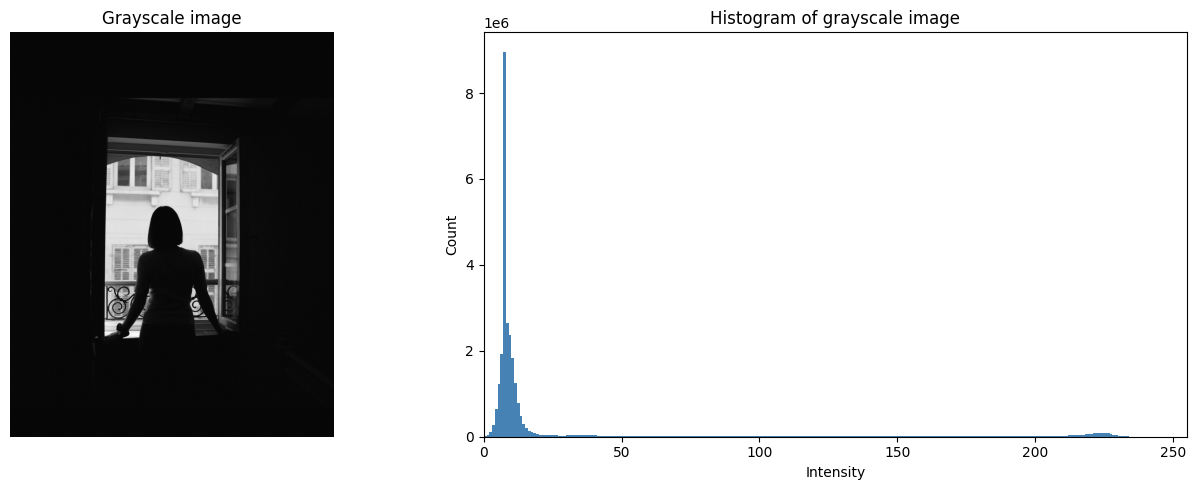

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(q4_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Grayscale image'); ax[0].axis('off')
ax[1].hist(q4_im.ravel(), bins=256, range=(0,256), color='steelblue')
ax[1].set_xlim(0, 255); ax[1].set_title('Histogram of grayscale image')
ax[1].set_xlabel('Intensity'); ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

### Question 04.a: Otsu thresholding

`cv.threshold(..., cv.THRESH_BINARY + cv.THRESH_OTSU)` automatically finds the threshold that best separates the two peaks of a bimodal histogram. The returned value is the optimal threshold.

In [4]:
# Apply Otsu thresholding
# First argument (0) is ignored when THRESH_OTSU flag is set — Otsu computes the threshold itself
otsu_thresh, q4_mask_raw = cv.threshold(q4_im, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
print(f'Otsu threshold value: {otsu_thresh}')

# cv.THRESH_BINARY gives: pixel > threshold → 255, else → 0
# In this image, the BRIGHT window becomes 255 and the DARK foreground becomes 0.
# We want the foreground (dark region: woman + room) as 255, so invert:
q4_foreground_mask = cv.bitwise_not(q4_mask_raw)

Otsu threshold value: 101.0


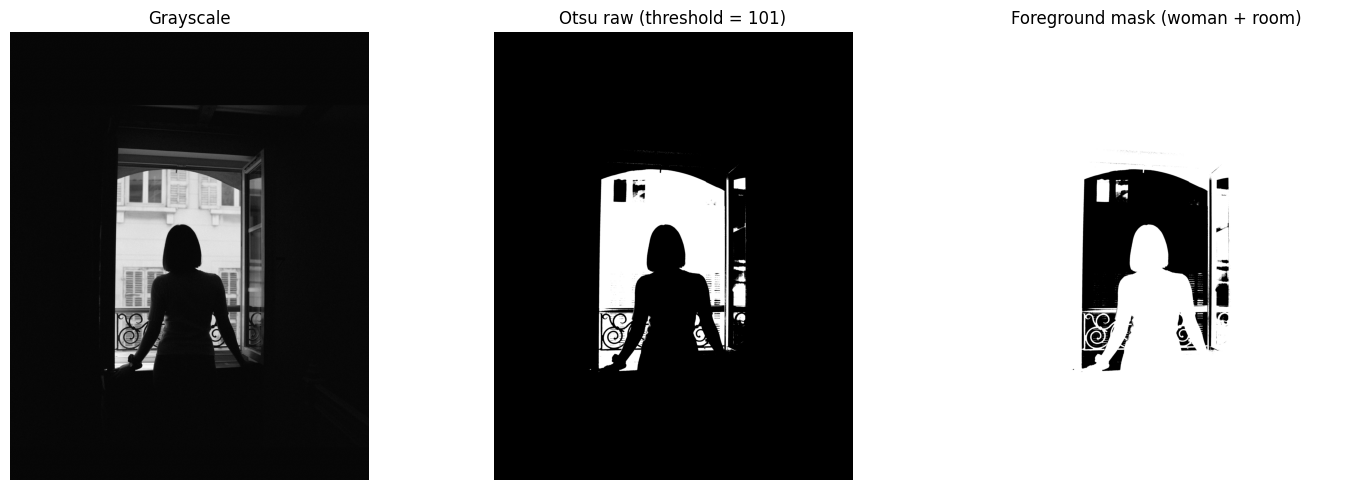

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(q4_im,              cmap='gray', vmin=0, vmax=255); ax[0].set_title('Grayscale'); ax[0].axis('off')
ax[1].imshow(q4_mask_raw,        cmap='gray', vmin=0, vmax=255); ax[1].set_title(f'Otsu raw (threshold = {int(otsu_thresh)})'); ax[1].axis('off')
ax[2].imshow(q4_foreground_mask, cmap='gray', vmin=0, vmax=255); ax[2].set_title('Foreground mask (woman + room)'); ax[2].axis('off')
plt.tight_layout()
plt.show()

### Question 04.b: Histogram equalization on foreground region only

Equalize **only** the pixels inside the foreground mask. The window region is left untouched.

**Method:**
1. Extract the foreground pixels (1D array).
2. Compute the histogram → CDF → LUT over just those pixels.
3. Apply the LUT to every pixel in the image, but **only write back** into foreground locations; leave the window region as it was.

In [7]:
def equalize_histogram_masked(image, mask):
    """
    Histogram equalization applied only to pixels where mask == 255.
    Pixels outside the mask are left unchanged.
    """
    L = 256

    # Step 1: extract foreground pixels only
    fg_pixels = image[mask == 255]
    total_fg = fg_pixels.size

    # Step 2: histogram of foreground only
    hist = np.bincount(fg_pixels, minlength=L)

    # Step 3: CDF and LUT
    cdf = np.cumsum(hist)
    t = np.round((L - 1) / total_fg * cdf).astype(np.uint8)

    # Step 4: apply LUT, but only where mask is set; keep the background unchanged
    g = image.copy()
    g[mask == 255] = t[image[mask == 255]]

    return g, t, hist

# Apply it
g_4, t_4, hist_4 = equalize_histogram_masked(q4_im, q4_foreground_mask)

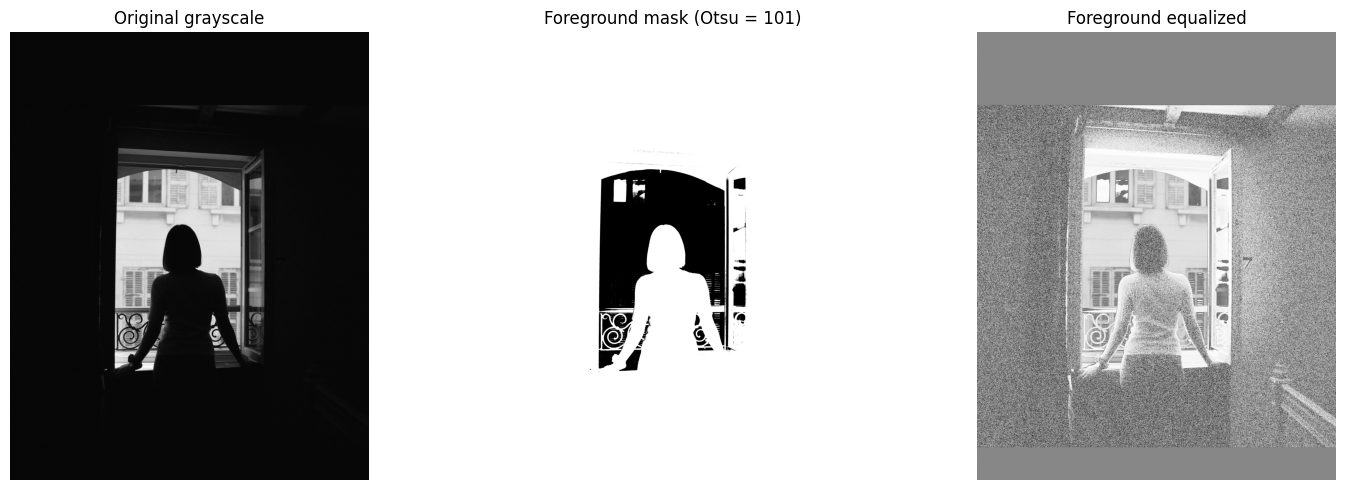

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(q4_im,              cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original grayscale'); ax[0].axis('off')
ax[1].imshow(q4_foreground_mask, cmap='gray', vmin=0, vmax=255); ax[1].set_title(f'Foreground mask (Otsu = {int(otsu_thresh)})'); ax[1].axis('off')
ax[2].imshow(g_4,                cmap='gray', vmin=0, vmax=255); ax[2].set_title('Foreground equalized'); ax[2].axis('off')
plt.tight_layout()
plt.show()

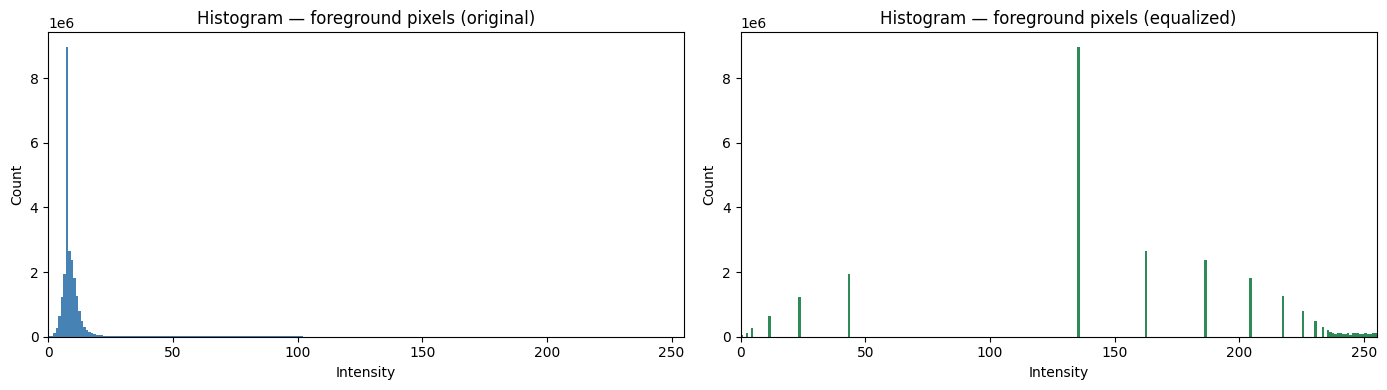

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(q4_im[q4_foreground_mask == 255].ravel(), bins=256, range=(0,256), color='steelblue')
ax[0].set_xlim(0, 255)
ax[0].set_title('Histogram — foreground pixels (original)')
ax[0].set_xlabel('Intensity'); ax[0].set_ylabel('Count')

ax[1].hist(g_4[q4_foreground_mask == 255].ravel(), bins=256, range=(0,256), color='seagreen')
ax[1].set_xlim(0, 255)
ax[1].set_title('Histogram — foreground pixels (equalized)')
ax[1].set_xlabel('Intensity'); ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()